# EDA – Gym Exercises Dataset

## Objectif

Vérifier que le fichier gym_exercises_dataset.csv est correctement chargé et obtenir une vue d’ensemble :

• dimensions du jeu de données (nombre de lignes et de colonnes) ;  
• typage des variables (champs textuels, listes de muscles, attributs techniques) ;  
• premières observations sur les valeurs manquantes et la présence éventuelle de doublons ;  
• cohérence générale du corpus avant analyse statistique et préparation NLP.


## Interprétation attendue

À partir de cette première inspection, il s’agira de commenter :

• la taille globale du dataset (nombre de lignes / colonnes) ;  
• la nature des variables (descriptifs textuels, attributs biomécaniques, catégories d’équipements) ;  
• la présence éventuelle de valeurs manquantes ou de champs textuels incomplets ;  
• l’existence (ou non) de doublons dans les données brutes ;  
• la cohérence générale des premières lignes (valeurs lisibles, descriptions complètes, muscles cohérents).

Cette interprétation sert de point de départ pour juger de la qualité du corpus et préparer les étapes suivantes : nettoyage, normalisation textuelle et structuration pour le traitement NLP du projet TrAIn.me.

## Configuration notebook

### Importation des librairies essentielles

In [46]:
import os
import textwrap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.ticker import PercentFormatter
import seaborn as sns
import kagglehub
import prince

from pathlib import Path
import sys

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy import stats
from scipy.stats import zscore

# === Localiser automatiquement le package 'themes' en remontant l'arborescence ===
root = Path.cwd()  # ex : .../train.me/src/notebooks/eda/health_fitness_dataset
themes_root = None

for p in [root, *root.parents]:
    if (p / "themes").is_dir():
        themes_root = p
        break

if themes_root is None:
    raise FileNotFoundError(
        f"Impossible de trouver le dossier 'themes' en partant de {root}. "
        "Vérifie l'arborescence : il doit exister un dossier 'themes/' quelque part au-dessus."
    )

if str(themes_root) not in sys.path:
    sys.path.insert(0, str(themes_root))

print("✅ Ajouté au PYTHONPATH :", themes_root)
print("📂 Contenu de", themes_root, ":", [x.name for x in themes_root.iterdir()])

from themes.theme_train_me import set_trainme_theme

✅ Ajouté au PYTHONPATH : c:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\src\notebooks
📂 Contenu de c:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\src\notebooks : ['eda', 'model_training', 'preprocessing', 'themes', '__init__.py']


#### Configuration d’affichage et thème TrAIn.me


In [2]:
# Options d’affichage pour les tableaux
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# =============================
# Thème TrAIn.me (Seaborn/Matplotlib)
# =============================
USE_DARK_THEME = True  # bascule possible vers un thème clair si besoin

palette_trainme = set_trainme_theme(
    context="talk",
    font_scale=1.05,
    use_dark=USE_DARK_THEME
)

palette_trainme


['#00E5FF', '#00BFFF', '#0A84FF', '#1E90FF', '#00FFFF', '#64D8FF']

### Activation du thème TrAIn.me

In [3]:
if USE_DARK_THEME:
    palette_trainme = set_trainme_theme(context="talk", font_scale=1.05, use_dark=True)
else:
    sns.set_style("ticks")              # style clair sobre, axes renforcés
    sns.set_context("talk", font_scale=1.05)
    palette_trainme = sns.color_palette("deep")  # palette par défaut sobre
    print("🎨 Style activé : 'ticks' → sobre, axes renforcés (présentation pro)")

# Exemple de vérification :
print("Palette active :", palette_trainme.as_hex() if hasattr(palette_trainme, "as_hex") else palette_trainme)


Palette active : ['#00E5FF', '#00BFFF', '#0A84FF', '#1E90FF', '#00FFFF', '#64D8FF']


### Chargement et inspection initiale

Cette section vise à charger le fichier gym_exercises_dataset.csv, vérifier ses dimensions
et obtenir un premier aperçu des données brutes. Elle reprend la même démarche que pour
les autres EDA du projet : contrôle du chargement, visualisation des premières lignes,
statistiques descriptives de base, analyse des valeurs manquantes et des doublons, puis
liste complète des colonnes disponibles.


#### Chargement du dataset gym_exercises_dataset.csv


In [4]:
# Téléchargement du dataset depuis Kaggle
dataset_path = kagglehub.dataset_download("rishitmurarka/gym-exercises-dataset")

# Recherche du fichier CSV dans le dossier téléchargé
csv_files = [f for f in os.listdir(dataset_path) if f.endswith(".csv")]
print("Fichiers trouvés :", csv_files)

# Construction du chemin complet vers le CSV
file_path = os.path.join(dataset_path, csv_files[0])


# Lecture du fichier CSV
df = pd.read_csv(file_path)

# Informations de confirmation
print("Dataset chargé avec succès !")
print(f"Dimensions : {df.shape[0]} lignes et {df.shape[1]} colonnes\n")


100%|██████████| 48.1k/48.1k [00:00<00:00, 574kB/s]

Extracting files...
Fichiers trouvés : ['gym_exercise_dataset.csv', 'stretch_exercise_dataset.csv']
Dataset chargé avec succès !
Dimensions : 617 lignes et 17 colonnes



#### Aperçu des premières lignes


In [5]:
df.head(10)


,Exercise Name,Equipment,Variation,Utility,Mechanics,Force,Preparation,Execution,Target_Muscles,Synergist_Muscles,Stabilizer_Muscles,Antagonist_Muscles,Dynamic_Stabilizer_Muscles,Main_muscle,Difficulty (1-5),Secondary Muscles,parent_id
0,Neck Flexion,Cable,No,Basic or Auxiliary,Isolated,Pull,Sit on bench facing away from middle pulley. P...,Move head away from pulley by bending neck for...,"Sternocleidomastoid,","None,","Rectus Abdominis, Obliques,",NaN,NaN,Neck,2,Sternocleidomastoid,NaN
1,Neck Flexion,Lever (plate loaded),No,Basic or Auxiliary,Isolated,Pull,Sit on seat in machine. Position padded lever ...,Move head forward by flexing neck until chin t...,"Sternocleidomastoid,","None,","Latissimus Dorsi, Deltoid, Posterior, Rhomboid...",NaN,NaN,Neck,2,Sternocleidomastoid,NaN
2,Lateral Neck Flexion,Lever (plate loaded),No,Auxiliary,Isolated,Pull,Sit on seat in machine with feet apart . Pos...,Move head down to side by laterally flexing ne...,"Sternocleidomastoid,","Splenius, Erector Spinae, Levator Scapulae, Tr...","Latissimus Dorsi, Pectoralis Major, Sternal, P...",NaN,NaN,Neck,2,"Sternocleidomastoid, Levator Scapulae",NaN
3,Neck Flexion,Lever (selectorized),No,Basic or Auxiliary,Isolated,Pull,Sit on seat in machine. Position padded lever ...,Move head forward by flexing neck until chin t...,"Sternocleidomastoid,","None,","Latissimus Dorsi, Deltoid, Posterior, Rhomboid...",NaN,NaN,Neck,2,Sternocleidomastoid,NaN
4,Lateral Neck Flexion,Lever (selectorized),No,Auxiliary,Isolated,Pull,Sit on seat in machine with feet apart. Positi...,Move head down to side by laterally flexing ne...,"Sternocleidomastoid,","Splenius, Erector Spinae, Levator Scapulae, Tr...","Latissimus Dorsi, Pectoralis Major, Sternal, P...",NaN,NaN,Neck,2,"Sternocleidomastoid, Levator Scapulae",NaN
5,Neck Flexion,Weighted,No,Basic or Auxiliary,Isolated,Pull,Place folded towel on weight plate. Lie supine...,Move head up by flexing neck until chin touche...,"Sternocleidomastoid,","None,","Rectus Abdominis, Obliques,",NaN,NaN,Neck,2,Sternocleidomastoid,NaN
6,Lateral Neck Flexion,Weighted,No,Auxiliary,Isolated,Pull,Place folded towel on weight plate. Lie on ben...,Move head up to side by laterally flexing neck...,"Sternocleidomastoid,","Splenius, Erector Spinae, Levator Scapulae, Tr...",NaN,NaN,NaN,Neck,2,"Sternocleidomastoid, Levator Scapulae",NaN
7,Wall Front Neck Bridge,Body Weight,No,Basic or Auxiliary,Isolated,Push & Pull,Place small or folded cushioned mat on wall or...,Roll down onto forehead until nose touches mat...,"Sternocleidomastoid,","Splenius, Trapezius, Upper, Levator Scapulae, ...","Rectus Abdominis, Obliques, Quadriceps,","Erector Spinae,",NaN,Neck,3,"Sternocleidomastoid, Upper Trapezius",NaN
8,Wall Side Neck Bridge,Body Weight,No,Auxiliary,Isolated,Pull,Place small or folded cushioned mat on column ...,Push side of head into mat and roll onto top o...,"Sternocleidomastoid,","Splenius, Trapezius, Upper, Levator Scapulae, ...","Gluteus Medius, Gluteus Minimus,",NaN,NaN,Neck,3,"Sternocleidomastoid, Upper Trapezius",NaN
9,Neck Flexion,Suspended,No,Basic or Auxiliary,Isolated,Pull,Place belt or strap around end of suspension t...,Increase angle of body by bowing head until ch...,"Sternocleidomastoid,","Splenius, Trapezius, Upper, Erector Spinae, Ce...",NaN,NaN,NaN,Neck,2,Sternocleidomastoid,NaN


#### Informations sur le typage, les valeurs manquantes et les doublons


In [6]:
# Typage et complétude globale
df_info = df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 617 entries, 0 to 616
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Exercise Name               617 non-null    object 
 1   Equipment                   617 non-null    object 
 2   Variation                   613 non-null    object 
 3   Utility                     617 non-null    object 
 4   Mechanics                   617 non-null    object 
 5   Force                       617 non-null    object 
 6   Preparation                 617 non-null    object 
 7   Execution                   617 non-null    object 
 8   Target_Muscles              617 non-null    object 
 9   Synergist_Muscles           615 non-null    object 
 10  Stabilizer_Muscles          489 non-null    object 
 11  Antagonist_Muscles          141 non-null    object 
 12  Dynamic_Stabilizer_Muscles  265 non-null    object 
 13  Main_muscle                 617 non

### Statistiques descriptives des variables numériques

In [7]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Difficulty (1-5),617.0,2.737439,0.893215,1.0,2.0,3.0,3.0,5.0
parent_id,161.0,307.248447,158.649536,14.0,181.0,341.0,449.0,615.0


### Analyse des valeurs manquantes et doublons

In [8]:
# Comptage des valeurs manquantes par colonne
missing_counts = df.isna().sum().sort_values(ascending=False)

print("\n🔎 Valeurs manquantes par colonne (top 20) :")
display(missing_counts.head(20))

# Comptage des doublons ligne à ligne
n_duplicates = df.duplicated().sum()
print(f"\n🧬 Nombre de doublons (lignes strictement identiques) : {n_duplicates}")


🔎 Valeurs manquantes par colonne (top 20) :


Antagonist_Muscles            476
parent_id                     456
Dynamic_Stabilizer_Muscles    352
Stabilizer_Muscles            128
Variation                       4
Synergist_Muscles               2
Secondary Muscles               1
Difficulty (1-5)                0
Main_muscle                     0
Exercise Name                   0
Equipment                       0
Execution                       0
Preparation                     0
Force                           0
Mechanics                       0
Utility                         0
Target_Muscles                  0
dtype: int64


🧬 Nombre de doublons (lignes strictement identiques) : 0


#### Liste complète des colonnes disponibles


In [9]:
print("\n--- Liste des colonnes du dataset ---")
print(df.columns.tolist())



--- Liste des colonnes du dataset ---
['Exercise Name', 'Equipment', 'Variation', 'Utility', 'Mechanics', 'Force', 'Preparation', 'Execution', 'Target_Muscles', 'Synergist_Muscles', 'Stabilizer_Muscles', 'Antagonist_Muscles', 'Dynamic_Stabilizer_Muscles', 'Main_muscle', 'Difficulty (1-5)', 'Secondary Muscles', 'parent_id']


## Statistiques descriptives et distribution des variables

### Objectif

Obtenir une vue d’ensemble chiffrée des variables numériques du dataset :

- résumer la distribution des variables disponibles (Difficulty (1-5), parent_id) ;
- repérer les ordres de grandeur, la dispersion et les éventuelles valeurs extrêmes ;
- identifier la répartition des niveaux de difficulté des exercices ;
- préparer l’identification d’outliers et la sélection de variables pertinentes pour la suite de l’analyse.


### Interprétation attendue

À l’issue de cette section, l’interprétation devra mettre en évidence :

- la distribution des niveaux de difficulté des exercices (répartition sur l’échelle 1–5) ;
- le rôle de parent_id comme identifiant de regroupement plutôt que comme variable métier ;
- la présence éventuelle de valeurs extrêmes ou atypiques sur les variables numériques ;
- les premières tendances sur la structure du corpus (exercices majoritairement faciles, intermédiaires ou difficiles).

Ces éléments guideront la suite de l’EDA, notamment la détection d’anomalies et la préparation des features pour les futurs modèles NLP et de recommandation.


### Statistiques descriptives globales


In [10]:
# --- Colonnes numériques disponibles ---
num_cols = df.select_dtypes(include="number").columns.tolist()
print(f"Variables numériques détectées ({len(num_cols)}) : {num_cols}")

# Statistiques descriptives de base
stats_num = df[num_cols].describe().T
display(stats_num)

# Quelques repères métier
if "Difficulty (1-5)" in df.columns:
    print(f"\nDifficulté moyenne : {df['Difficulty (1-5)'].mean():.2f} / 5")
    print("Répartition des niveaux de difficulté :")
    display(df["Difficulty (1-5)"].value_counts().sort_index())


Variables numériques détectées (2) : ['Difficulty (1-5)', 'parent_id']


,count,mean,std,min,25%,50%,75%,max
Difficulty (1-5),617.0,2.737439,0.893215,1.0,2.0,3.0,3.0,5.0
parent_id,161.0,307.248447,158.649536,14.0,181.0,341.0,449.0,615.0



Difficulté moyenne : 2.74 / 5
Répartition des niveaux de difficulté :


Difficulty (1-5)
1     41
2    209
3    254
4     97
5     16
Name: count, dtype: int64

### Distribution des variables clés


Variables numériques représentées : ['Difficulty (1-5)']


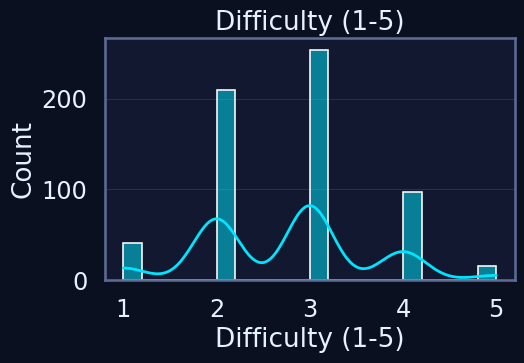

In [11]:
# On garde les variables numériques réellement intéressantes
num_vars = [c for c in num_cols if c != "parent_id"]  # parent_id = identifiant technique
print(f"Variables numériques représentées : {num_vars}")

n = len(num_vars)
if n == 0:
    print("ℹ️ Aucune variable numérique pertinente à visualiser.")
else:
    n_cols = 2
    n_rows = int(np.ceil(n / n_cols))

    plt.figure(figsize=(5 * n_cols, 4 * n_rows))

    for i, col in enumerate(num_vars, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(df[col], bins=20, kde=True)
        plt.title(col)
        plt.grid(True, axis="y")

    plt.tight_layout()
    plt.show()


### Boxplots pour repérer les outliers


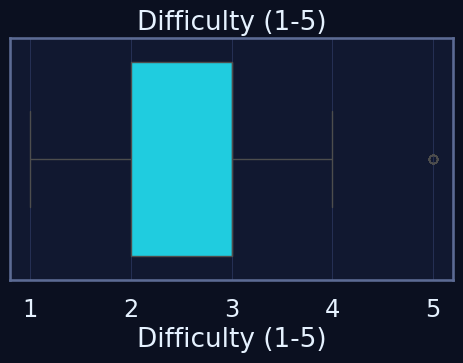

In [12]:
if num_vars:
    plt.figure(figsize=(5 * len(num_vars), 4))

    for i, col in enumerate(num_vars, 1):
        plt.subplot(1, len(num_vars), i)
        sns.boxplot(x=df[col])
        plt.title(col)
        plt.grid(True, axis="x")

    plt.tight_layout()
    plt.show()
else:
    print("ℹ️ Aucun boxplot pertinent à afficher (pas de variable numérique métier).")


### Statistiques descriptives enrichies


In [13]:
if num_cols:
    desc = df[num_cols].describe().T
    desc["missing_%"] = df[num_cols].isna().mean() * 100
    desc["zeros_%"] = (df[num_cols] == 0).mean() * 100
    desc["skew"] = df[num_cols].skew()
    desc["kurt"] = df[num_cols].kurt()

    display(desc.sort_values("std", ascending=False))
else:
    print("ℹ️ Aucune variable numérique disponible pour des statistiques enrichies.")


,count,mean,std,min,25%,50%,75%,max,missing_%,zeros_%,skew,kurt
parent_id,161.0,307.248447,158.649536,14.0,181.0,341.0,449.0,615.0,73.905997,0.0,-0.197914,-1.036210
Difficulty (1-5),617.0,2.737439,0.893215,1.0,2.0,3.0,3.0,5.0,0.000000,0.0,0.197199,-0.175658


### Détection rapide d’outliers (IQR)


In [14]:
iqr_report = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    iqr_report[col] = len(outliers)

iqr_df = pd.DataFrame.from_dict(iqr_report, orient="index", columns=["outliers"])
iqr_df.sort_values("outliers", ascending=False)


,outliers
Difficulty (1-5),16
parent_id,0


### Aperçu corrélations (sous-ensemble lisible)


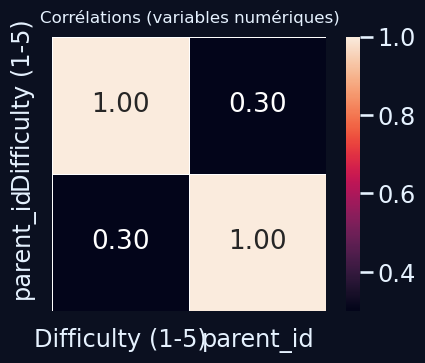

In [15]:
if len(num_cols) >= 2:
    subset_cols = num_cols  # très peu de variables numériques ici
    corr = df[subset_cols].corr(numeric_only=True)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        square=True,
        cbar=True,
        linewidths=0.5,
    )
    plt.title("Corrélations (variables numériques)", fontsize=12, pad=10)
    plt.tight_layout()
    plt.show()
else:
    print("ℹ️ Corrélation non pertinente : une seule variable numérique disponible.")


## Visualisation univariée

### Objectif

Compléter les statistiques descriptives par une analyse visuelle des distributions
des variables numériques du dataset.

Dans le cas du Gym Exercises Dataset, il s’agit principalement de :

- visualiser la répartition des niveaux de difficulté (Difficulty (1-5)) ;
- vérifier l’éventuelle présence de valeurs extrêmes ou atypiques ;
- confirmer le rôle de parent_id comme identifiant technique plus que comme
  variable métier continue ;
- préparer les décisions de nettoyage ou de regroupement éventuel pour la suite
  de l’analyse.


### Interprétation attendue

À l’issue de cette section, l’analyse devra :

- décrire la forme de la distribution de Difficulty (1-5) (niveau dominant,
  éventuel déséquilibre entre exercices faciles et difficiles) ;
- signaler la présence ou non de niveaux très peu représentés ;
- confirmer le caractère peu informatif de parent_id en tant que variable
  numérique (utilisation structurelle, valeurs dispersées) ;
- identifier visuellement d’éventuels points atypiques qui pourraient justifier
  un traitement spécifique dans les étapes suivantes.

Ces éléments complètent la lecture purement chiffrée et orientent les choix de
préparation des features pour les futurs modèles NLP et de recommandation.


### Sélection robuste des variables numériques à visualiser


In [16]:
# --- Sélection des variables numériques pertinentes pour la visualisation univariée ---

num_cols = df.select_dtypes(include=["number"]).columns.tolist()
print("Variables numériques détectées :", num_cols)

# On conserve Difficulty (1-5) comme variable métier principale
# et on laisse parent_id optionnel (identifiant technique de regroupement)
vars_univariate = [c for c in num_cols if c == "Difficulty (1-5)"]

print("Variables retenues pour la visualisation univariée :", vars_univariate)


Variables numériques détectées : ['Difficulty (1-5)', 'parent_id']
Variables retenues pour la visualisation univariée : ['Difficulty (1-5)']


### Visualisation des distributions univariées (hist + KDE)


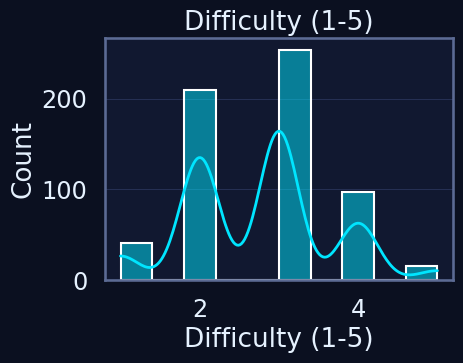

In [17]:
if not vars_univariate:
    print("ℹ️ Aucune variable numérique pertinente à visualiser.")
else:
    n = len(vars_univariate)
    n_cols = min(3, n)
    n_rows = int(np.ceil(n / n_cols))

    plt.figure(figsize=(5 * n_cols, 4 * n_rows))

    for i, col in enumerate(vars_univariate, start=1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(df[col], bins=10, kde=True)
        plt.title(col)
        plt.grid(True, axis="y")

    plt.tight_layout()
    plt.show()


### Boxplots univariés pour détection visuelle d'outliers


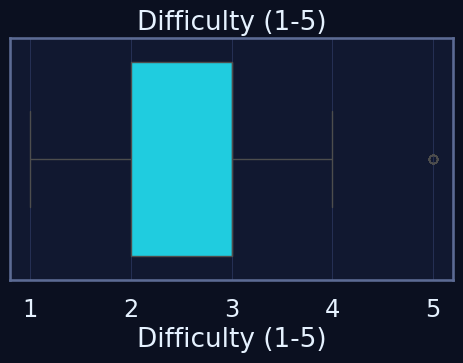

In [18]:
if not vars_univariate:
    print("ℹ️ Aucun boxplot pertinent à afficher (pas de variable numérique métier).")
else:
    plt.figure(figsize=(5 * len(vars_univariate), 4))

    for i, col in enumerate(vars_univariate, start=1):
        plt.subplot(1, len(vars_univariate), i)
        sns.boxplot(x=df[col])
        plt.title(col)
        plt.grid(True, axis="x")

    plt.tight_layout()
    plt.show()


## Visualisation bivariée

### Objectif

Explorer les relations entre la variable numérique de difficulté (*Difficulty (1-5)*)
et les principales variables catégorielles du corpus (Equipment, Main_muscle,
Utility, etc.).

L’objectif est de :

- comprendre comment la difficulté se répartit selon les types d’équipement
  et les groupes musculaires ;
- analyser les co-occurrences entre catégories (combinaisons Equipment ×
  Main_muscle, par exemple) ;
- identifier les types d’exercices les plus représentés au sein des machines
  les plus utilisées.

Ces éléments permettront de mieux structurer le catalogue d’exercices pour les
futurs modèles de recommandation et de NLP.


### Interprétation attendue

À l’issue de cette section, l’analyse devra :

- mettre en évidence les équipements associés aux niveaux de difficulté les
  plus élevés ou les plus faibles ;
- décrire les couples de catégories fréquents (par exemple Equipment ×
  Main_muscle) et leurs patterns ;
- visualiser la répartition des types d’exercices (Utility) au sein des
  équipements les plus présents ;
- dégager des pistes sur la manière dont la difficulté se combine avec
  l’équipement et les groupes musculaires.

Ces observations aideront à concevoir des règles métiers et à orienter le
pré-traitement des textes (catégorisation, regroupements, mappings pour le NLP).


### Relations catégorielles ↔ numérique (Difficulty (1-5))

Dans un premier temps, on observe comment la difficulté moyenne des exercices
évolue selon l’équipement utilisé et le muscle principal ciblé.


,count,mean
Equipment,,
Assisted (machine),3,4.000000
Assisted (partner),2,4.000000
Band-assisted,7,3.857143
Suspension,2,3.500000
Self-assisted,6,3.500000
Plyometric,2,3.500000
Self-assisted​​​​​​​,5,3.400000
Body Weight,76,3.315789
Weighted,34,3.205882


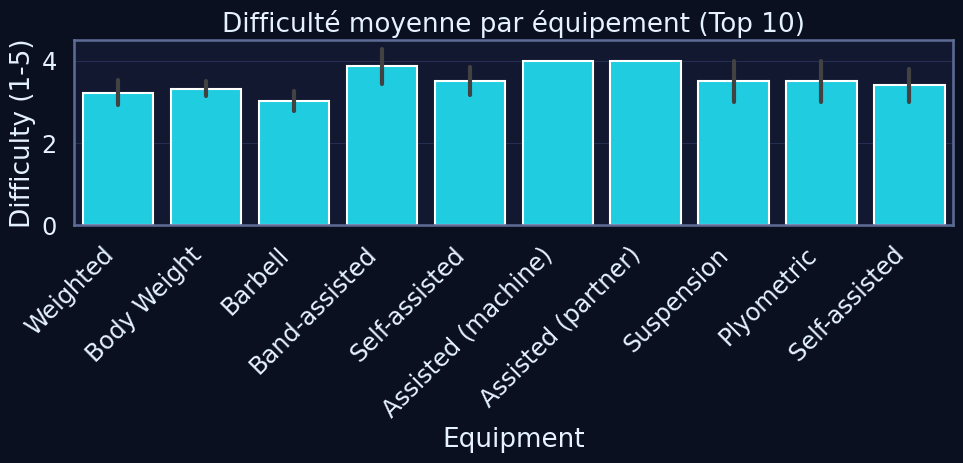

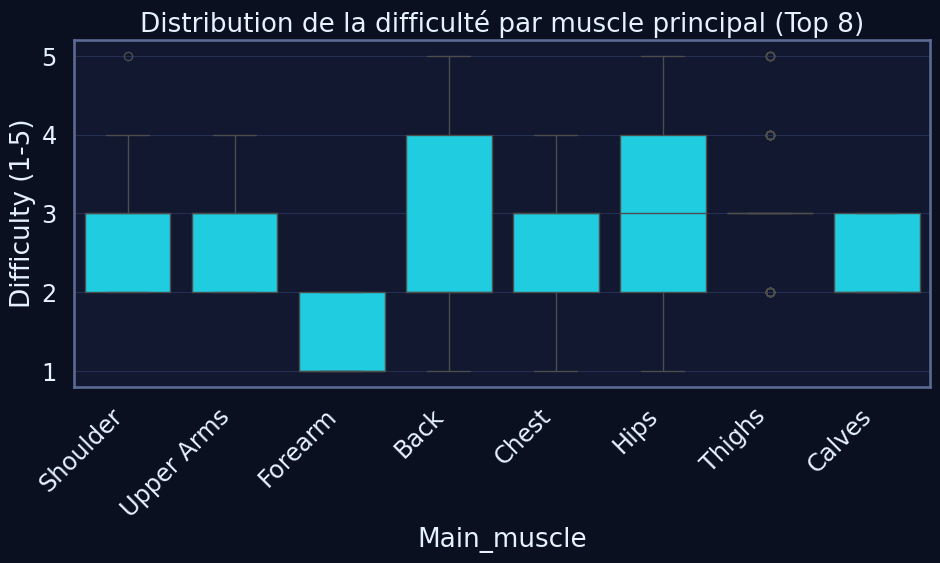

In [19]:
rating_col = "Difficulty (1-5)"

# --- Difficulté moyenne par équipement ---
equip_rating = (
    df.groupby("Equipment")[rating_col]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

display(equip_rating.head(15))

plt.figure(figsize=(10, 5))
top_equip = equip_rating.head(10).index

sns.barplot(
    data=df[df["Equipment"].isin(top_equip)],
    x="Equipment",
    y=rating_col,
    estimator=np.mean,
)
plt.xticks(rotation=45, ha="right")
plt.title("Difficulté moyenne par équipement (Top 10)")
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

# --- Difficulté par muscle principal (boxplots) ---
plt.figure(figsize=(10, 6))
top_muscles = (
    df["Main_muscle"]
    .value_counts()
    .head(8)
    .index
)

sns.boxplot(
    data=df[df["Main_muscle"].isin(top_muscles)],
    x="Main_muscle",
    y=rating_col,
)
plt.xticks(rotation=45, ha="right")
plt.title("Distribution de la difficulté par muscle principal (Top 8)")
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()


### Co-occurrences entre catégories (crosstab + heatmaps)

On s’intéresse ensuite aux co-occurrences entre catégories, par exemple les
combinaisons Equipment × Main_muscle, pour repérer les couples les plus
fréquents.


Main_muscle,Back,Calves,Chest,Forearm,Hips,Shoulder,Thighs,Upper Arms
Equipment,,,,,,,,
Barbell,5,3,5,3,14,5,15,7
Body Weight,10,4,8,0,26,4,14,7
Cable,21,4,12,4,18,16,9,15
Dumbbell,7,4,7,5,8,15,8,8
Lever (plate loaded),16,9,7,3,14,7,12,5
Lever (selectorized),11,8,13,6,14,6,12,7
Sled,1,12,1,0,9,1,6,1
Weighted,4,1,2,0,16,0,5,2


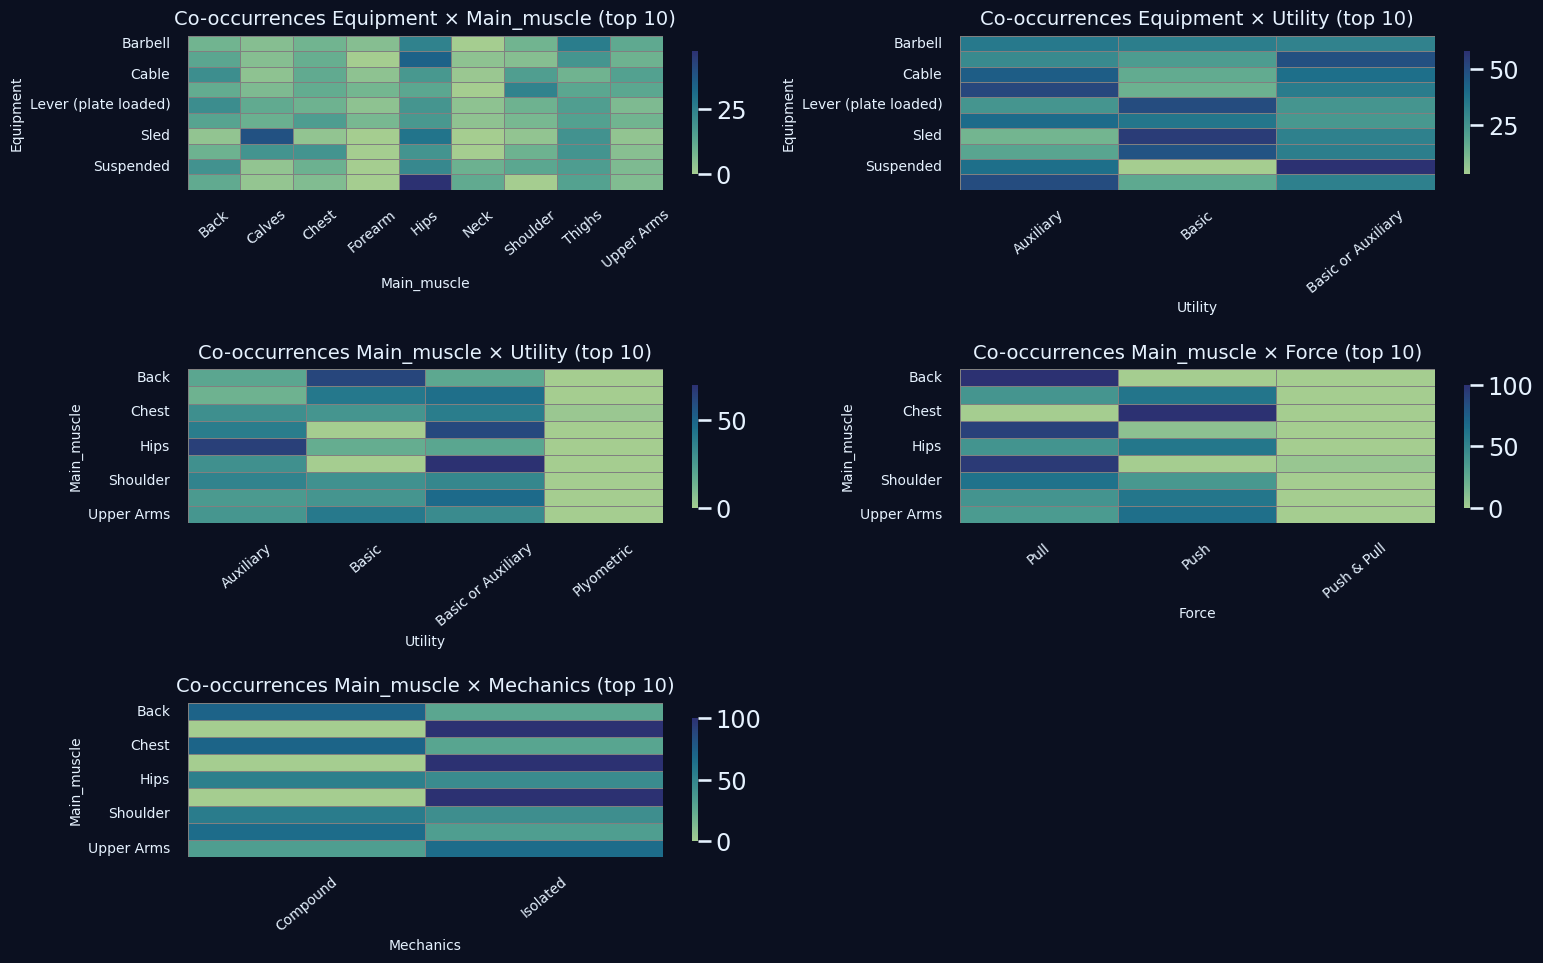

In [23]:
# Sélection d'un sous-ensemble lisible : top équipements / top muscles
top_equip_for_cooc = df["Equipment"].value_counts().head(8).index
top_muscles_for_cooc = df["Main_muscle"].value_counts().head(8).index

subset = df[
    df["Equipment"].isin(top_equip_for_cooc)
    & df["Main_muscle"].isin(top_muscles_for_cooc)
]

cooc = pd.crosstab(subset["Equipment"], subset["Main_muscle"])

display(cooc)

def plot_crosstab_heatmaps(
    df,
    pairs,
    top_k=12,
    normalize=None,     # None | "row" | "col"  (pourcentages)
    annotate=False,     # True pour afficher les valeurs
    log_color=False,    # True pour mieux voir les faibles valeurs
    figsize=(16, 9),
    title_fontsize=13,
    tick_fontsize=9,
    label_rotation_x=30,
    label_rotation_y=0,
    cbar_shrink=0.85
):
    """Heatmaps propres et lisibles pour analyser les co-occurrences de catégories."""
    if not pairs:
        print("ℹ️ Aucune paire de catégories disponible.")
        return

    n = len(pairs)
    ncols = 2
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
    axes = np.atleast_1d(axes).ravel()

    for i, (a, b) in enumerate(pairs):
        ax = axes[i]

        # Top-k pour réduire la cardinalité (plus lisible)
        a_top = df[a].value_counts().index[:top_k]
        b_top = df[b].value_counts().index[:top_k]
        sub = df[df[a].isin(a_top) & df[b].isin(b_top)]

        ct = pd.crosstab(sub[a], sub[b])

        # Normalisation optionnelle en pourcentages
        if normalize in {"row", "col"}:
            axis = 1 if normalize == "row" else 0
            ct = (
                ct.div(
                    ct.sum(axis=axis).replace(0, np.nan),
                    axis=1-axis
                ) * 100
            ).round(1)

        # Palette & échelle adaptées
        heatmap_kwargs = dict(
            cmap="crest",
            linewidths=0.4,
            linecolor="grey",
            cbar_kws={"shrink": cbar_shrink},
            square=False,
        )
        if log_color and normalize is None:
            # Log uniquement pour les comptes bruts (pas en %)
            vmin = max(ct.replace(0, np.nan).min().min(), 1e-6)
            vmax = ct.max().max()
            heatmap_kwargs["norm"] = LogNorm(vmin=vmin, vmax=vmax)

        # Annotations optionnelles
        if annotate:
            sns.heatmap(
                ct,
                ax=ax,
                **heatmap_kwargs,
                annot=True,
                fmt=".1f" if normalize else "g",
                annot_kws={"fontsize": max(tick_fontsize - 1, 7)},
            )
        else:
            sns.heatmap(ct, ax=ax, **heatmap_kwargs)

        ax.set_title(
            f"Co-occurrences {a} × {b} (top {top_k})",
            fontsize=title_fontsize,
            pad=8,
        )
        ax.set_xlabel(b, fontsize=10)
        ax.set_ylabel(a, fontsize=10)

        # Ticks propres
        ax.tick_params(axis="x", labelsize=tick_fontsize, rotation=label_rotation_x)
        ax.tick_params(axis="y", labelsize=tick_fontsize, rotation=label_rotation_y)
        ax.grid(False)

    # Masquer axes vides si nombre impair
    for j in range(i + 1, nrows * ncols):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


# ============================================================
# Sélection des paires & appel (version Gym Exercises Dataset)
# ============================================================
pairs = []
if {"Equipment", "Main_muscle"}.issubset(df.columns):
    pairs.append(("Equipment", "Main_muscle"))
if {"Equipment", "Utility"}.issubset(df.columns):
    pairs.append(("Equipment", "Utility"))
if {"Main_muscle", "Utility"}.issubset(df.columns):
    pairs.append(("Main_muscle", "Utility"))
if {"Main_muscle", "Force"}.issubset(df.columns):
    pairs.append(("Main_muscle", "Force"))
if {"Main_muscle", "Mechanics"}.issubset(df.columns):
    pairs.append(("Main_muscle", "Mechanics"))

# 👉 Paramètres recommandés pour notre dataset :
# - normalize="row" pour lire des ratios par catégorie de ligne
# - annotate=False pour éviter la surcharge visuelle
# - log_color=False car on travaille en %
plot_crosstab_heatmaps(
    df,
    pairs=pairs,
    top_k=10,
    normalize="row",     # None = comptes bruts ; "row"/"col" = pourcentages
    annotate=False,
    log_color=False,
    figsize=(16, 10),
    title_fontsize=14,
    tick_fontsize=10,
    label_rotation_x=40,
    label_rotation_y=0,
    cbar_shrink=0.8,
)



### Comptage empilé (stacked) : Type au sein du top Equipment

Pour finir, on observe la répartition des types d’exercices (Utility :
Basic or Auxiliary / Auxiliary, etc.) au sein des équipements les plus
représentés.


Utility,Auxiliary,Basic,Basic or Auxiliary
Equipment,,,
Barbell,20,19,18
Body Weight,22,17,37
Cable,45,17,39
Dumbbell,32,9,21
Lever (plate loaded),19,38,19
Lever (selectorized),32,29,19


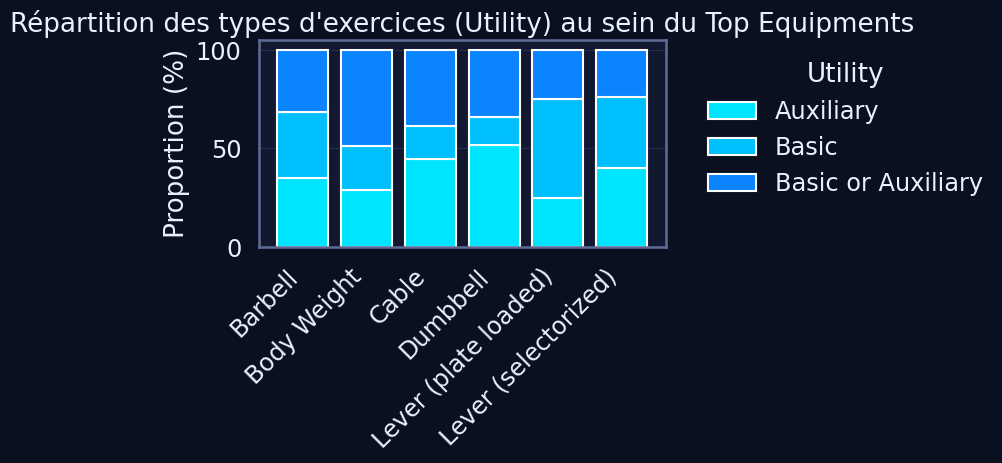

In [24]:
# On retient les équipements les plus fréquents
top_equip_for_stack = df["Equipment"].value_counts().head(6).index
stack_subset = df[df["Equipment"].isin(top_equip_for_stack)].copy()

crosstab_utility = pd.crosstab(stack_subset["Equipment"], stack_subset["Utility"])
display(crosstab_utility)

# Normalisation en pourcentage pour lecture plus intuitive
crosstab_utility_pct = crosstab_utility.div(crosstab_utility.sum(axis=1), axis=0) * 100

plt.figure(figsize=(9, 5))

bottom = np.zeros(len(crosstab_utility_pct))
x = np.arange(len(crosstab_utility_pct.index))

for utility in crosstab_utility_pct.columns:
    values = crosstab_utility_pct[utility].values
    plt.bar(
        x,
        values,
        bottom=bottom,
        label=utility,
    )
    bottom += values

plt.xticks(x, crosstab_utility_pct.index, rotation=45, ha="right")
plt.ylabel("Proportion (%)")
plt.title("Répartition des types d'exercices (Utility) au sein du Top Equipments")
plt.legend(title="Utility", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


## Analyse multivariée (ACM)

### Objectif

L’objectif de cette section est d’explorer les relations entre les variables
catégorielles du Gym Exercises Dataset à l’aide d’une Analyse des
Correspondances Multiples (ACM).

L’ACM permet de :

- réduire la dimensionalité des données catégorielles ;
- visualiser les proximités et oppositions entre exercices ;
- analyser les regroupements structurels (Equipment, Mechanics, Force,
  Utility, Main_muscle) ;
- comprendre quelles modalités contribuent le plus aux axes principaux.

Cette méthode est particulièrement adaptée à un dataset où l’information
est majoritairement textuelle.


### Interprétation attendue

L’analyse doit permettre d’identifier :

- les groupes d’exercices proches selon leur mécanique, leur type
  d’équipement ou leurs muscles ciblés ;
- les modalités qui structurent le plus les deux premiers axes de l’ACM ;
- les positions atypiques ou éloignées traduisant des exercices rares ou
  spécifiques ;
- les clusters potentiels d’exercices partageant des caractéristiques
  communes.

Ces observations permettront d’alimenter la préparation NLP, la logique
de recommandation et les mappings métier du projet TrAIn.me.


### Préparation des données pour l'Analyse des Correspondances Multiples (ACM)

On sélectionne les variables catégorielles les plus pertinentes du
corpus et on les prépare pour l’ACM (codage factoriel, gestion des
valeurs manquantes, filtre des modalités rares).


In [29]:
# === Sélection pertinente des variables catégorielles ===
cat_cols = [
    "Equipment",
    "Utility",
    "Mechanics",
    "Force",
    "Main_muscle",
]

# Filtre pour garder un dataset propre
df_acm = df[cat_cols].copy()

# Remplacement des valeurs manquantes par "Missing"
df_acm = df_acm.fillna("Missing")

print("Variables catégorielles utilisées pour l'ACM :")
df_acm.head()


Variables catégorielles utilisées pour l'ACM :


,Equipment,Utility,Mechanics,Force,Main_muscle
0,Cable,Basic or Auxiliary,Isolated,Pull,Neck
1,Lever (plate loaded),Basic or Auxiliary,Isolated,Pull,Neck
2,Lever (plate loaded),Auxiliary,Isolated,Pull,Neck
3,Lever (selectorized),Basic or Auxiliary,Isolated,Pull,Neck
4,Lever (selectorized),Auxiliary,Isolated,Pull,Neck


In [30]:
# Réduction de cardinalité : regroupement des classes rares sous 'Other'
def simplify_categories(s, top_k=12):
    vc = s.value_counts(dropna=False)
    keep = set(vc.index[:top_k])
    return s.where(s.isin(keep), other="Other")

for c in cat_cols:
    df_acm[c] = simplify_categories(df_acm[c].astype(str), top_k=12)

print(f"Variables retenues pour l'ACM : {cat_cols}")
for c in cat_cols:
    print(f"- {c}: {df_acm[c].nunique()} modalités après simplification.")

Variables retenues pour l'ACM : ['Equipment', 'Utility', 'Mechanics', 'Force', 'Main_muscle']
- Equipment: 13 modalités après simplification.
- Utility: 4 modalités après simplification.
- Mechanics: 2 modalités après simplification.
- Force: 3 modalités après simplification.
- Main_muscle: 9 modalités après simplification.


### Analyse des Correspondances Multiples (MCA)

On applique une ACM via la librairie prince, adaptée aux données
catégorielles.


In [31]:
# --- Fit ACM (engine explicite) ---
mca = prince.MCA(
    n_components=3,
    n_iter=10,
    copy=True,
    check_input=True,
    engine="sklearn",   # ✅ exigé par prince>=0.16
    random_state=42
).fit(df_acm)

X_mca = mca.transform(df_acm)  # coords individus (Dim1, Dim2, Dim3, ...)

# --- Récupération robuste de l'inertie expliquée ---
def explained_inertia_percent(mca_obj):
    # 1) Certains prince exposent une propriété
    if hasattr(mca_obj, "explained_inertia_"):
        val = getattr(mca_obj, "explained_inertia_")
        # Peut être une liste/ndarray... ou une méthode (rare)
        if callable(val):
            vals = np.array(val())
        else:
            vals = np.array(val)
        return vals * 100.0

    # 2) D’autres exposent eigenvalues_ (valeurs propres) → normalisation
    if hasattr(mca_obj, "eigenvalues_"):
        eig = np.array(mca_obj.eigenvalues_)
        eig = eig[~np.isnan(eig)]  # sécurité
        if eig.sum() > 0:
            return (eig / eig.sum()) * 100.0

    # 3) Fallback (aucune info exploitable)
    return np.array([])

explained = explained_inertia_percent(mca)
if explained.size:
    print(f"Variance expliquée par les 3 premières dimensions : {explained[:3].sum():.2f}%")
else:
    print("⚠️ Impossible de récupérer l'inertie expliquée (API prince inhabituelle).")


Variance expliquée par les 3 premières dimensions : 100.00%


### Variance expliquée par dimension

Les pourcentages de variance indiquent la capacité de chaque axe
à représenter la structure globale des données.


C:\Users\fback\AppData\Local\Temp\ipykernel_15092\3019530282.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[f"Dim{i+1}" for i in range(dims)], y=explained[:dims], palette=palette_trainme)
C:\Users\fback\AppData\Local\Temp\ipykernel_15092\3019530282.py:4: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.barplot(x=[f"Dim{i+1}" for i in range(dims)], y=explained[:dims], palette=palette_trainme)


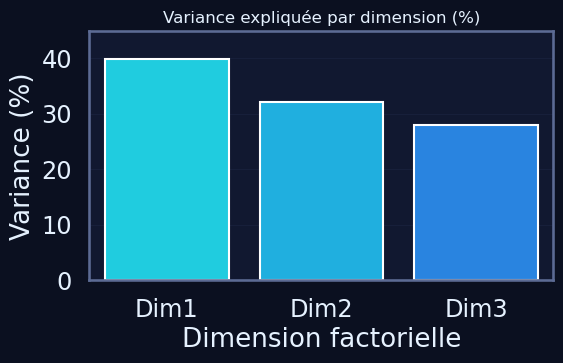

In [32]:
dims = min(3, len(explained)) if explained.size else 0
if dims:
    plt.figure(figsize=(6,4))
    sns.barplot(x=[f"Dim{i+1}" for i in range(dims)], y=explained[:dims], palette=palette_trainme)
    plt.title("Variance expliquée par dimension (%)", fontsize=12)
    plt.ylabel("Variance (%)")
    plt.xlabel("Dimension factorielle")
    plt.ylim(0, max(10, float(explained[:dims].max()) + 5))
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("ℹ️ Pas de graphique de variance (inertie indisponible).")

### Visualisation factorielle des individus (Dim 1 & 2)


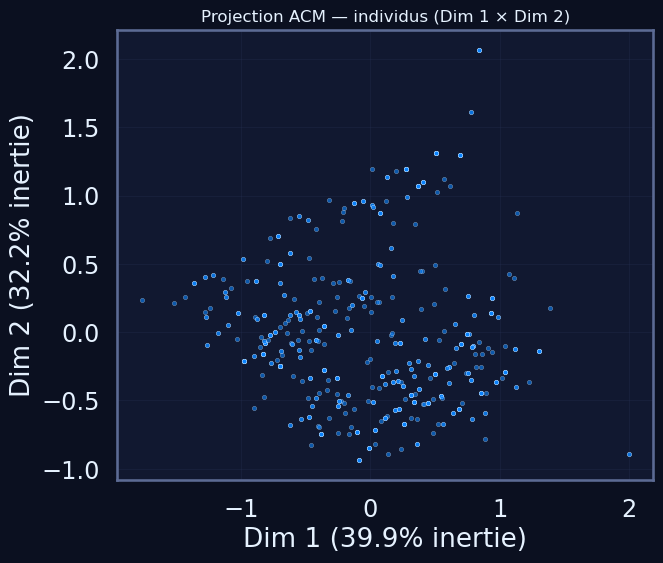

In [34]:
if X_mca.shape[1] >= 2:
    plt.figure(figsize=(7,6))
    sns.scatterplot(x=X_mca.iloc[:,0], y=X_mca.iloc[:,1],
                    s=10, alpha=0.6, color=palette_trainme[2])
    lab_x = f"Dim 1 ({explained[0]:.1f}% inertie)" if explained.size>=1 else "Dim 1"
    lab_y = f"Dim 2 ({explained[1]:.1f}% inertie)" if explained.size>=2 else "Dim 2"
    plt.xlabel(lab_x); plt.ylabel(lab_y)
    plt.title("Projection ACM — individus (Dim 1 × Dim 2)", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("ℹ️ Moins de 2 dimensions disponibles pour la projection des individus.")

### Visualisation des modalités (categories)

Les modalités proches sur le plan factoriel partagent des comportements
ou caractéristiques communes.

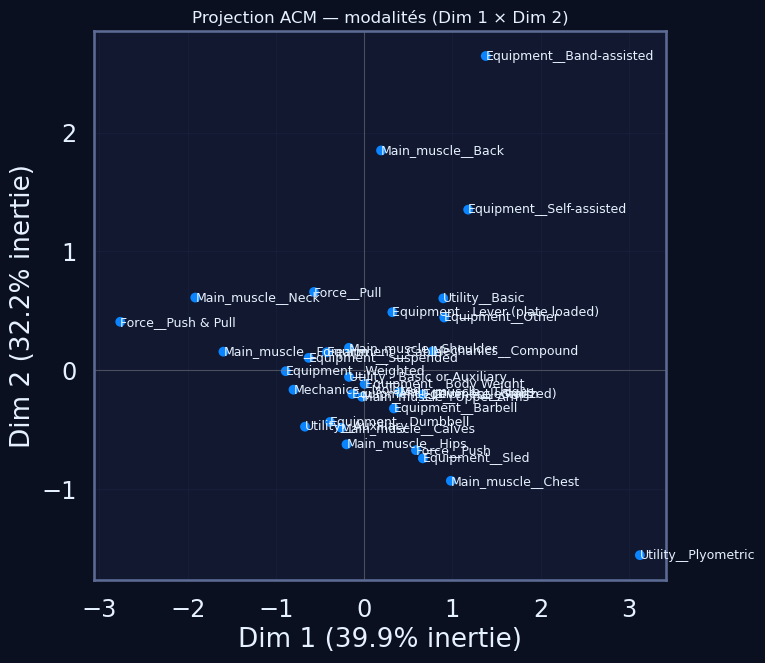

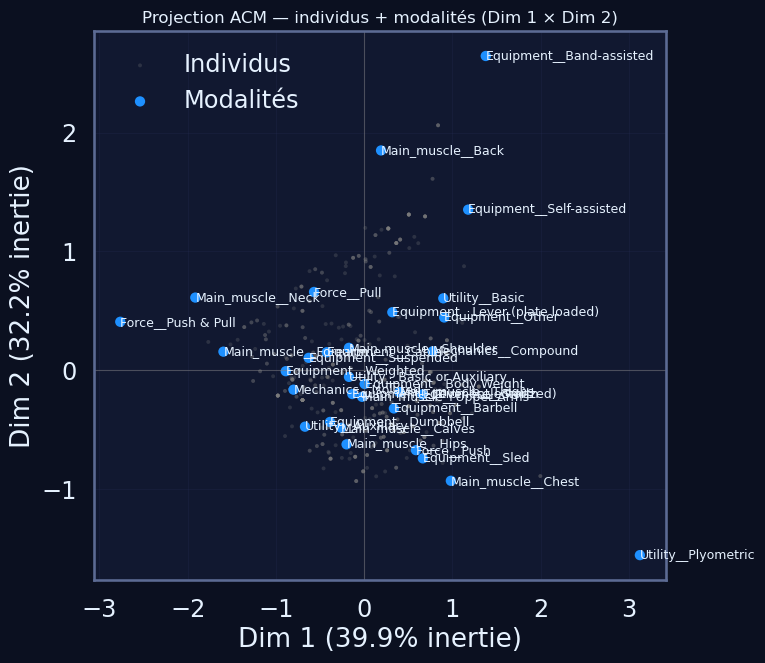

In [35]:
# Récupération des % d'inertie (si dispo) pour les labels d'axes
def _get_explained_pct(mca_obj):
    try:
        vals = mca_obj.explained_inertia_
        if callable(vals): vals = vals()
        return np.array(vals) * 100.0
    except Exception:
        try:
            eig = np.array(mca_obj.eigenvalues_)
            eig = eig[~np.isnan(eig)]
            return (eig / eig.sum()) * 100.0 if eig.sum() > 0 else np.array([])
        except Exception:
            return np.array([])

exp = _get_explained_pct(mca)

# Coordonnées des modalités (colonnes)
cols = mca.column_coordinates(df_acm)   # index = "colonne_modalité"
# Coordonnées des individus (lignes) — optionnel
try:
    rows = mca.row_coordinates(df_acm)
except Exception:
    rows = None

# --------- Plot des modalités uniquement (clair et lisible) ---------
plt.figure(figsize=(8, 7))
ax = plt.gca()

sns.scatterplot(x=cols[0], y=cols[1], s=50, color=palette_trainme[2], edgecolor="none", ax=ax)

# Annotations propres des modalités
for label, (x, y) in cols[[0, 1]].iterrows():
    ax.text(x, y, str(label), fontsize=9, ha="left", va="center")

xl = f"Dim 1 ({exp[0]:.1f}% inertie)" if exp.size >= 1 else "Dim 1"
yl = f"Dim 2 ({exp[1]:.1f}% inertie)" if exp.size >= 2 else "Dim 2"
ax.set_xlabel(xl); ax.set_ylabel(yl)
ax.set_title("Projection ACM — modalités (Dim 1 × Dim 2)", fontsize=12)
ax.axhline(0, color="grey", lw=0.8, alpha=0.5); ax.axvline(0, color="grey", lw=0.8, alpha=0.5)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

# --------- Variante avec individus (en arrière-plan), optionnelle ---------
if rows is not None and rows.shape[1] >= 2:
    plt.figure(figsize=(8, 7))
    ax = plt.gca()

    # Individus en arrière-plan
    sns.scatterplot(x=rows[0], y=rows[1], s=8, alpha=0.25, color="grey", edgecolor="none", ax=ax, label="Individus")

    # Modalités au premier plan
    sns.scatterplot(x=cols[0], y=cols[1], s=55, color=palette_trainme[3], edgecolor="none", ax=ax, label="Modalités")
    for label, (x, y) in cols[[0, 1]].iterrows():
        ax.text(x, y, str(label), fontsize=9, ha="left", va="center")

    xl = f"Dim 1 ({exp[0]:.1f}% inertie)" if exp.size >= 1 else "Dim 1"
    yl = f"Dim 2 ({exp[1]:.1f}% inertie)" if exp.size >= 2 else "Dim 2"
    ax.set_xlabel(xl); ax.set_ylabel(yl)
    ax.set_title("Projection ACM — individus + modalités (Dim 1 × Dim 2)", fontsize=12)
    ax.axhline(0, color="grey", lw=0.8, alpha=0.5); ax.axvline(0, color="grey", lw=0.8, alpha=0.5)
    ax.legend(loc="best", frameon=False)
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()


### Contributions des modalités aux axes principaux

Ces contributions déterminent quelles catégories structurent le plus les
axes factoriels, et donc la forme globale du plan.


In [36]:
# Récupération des contributions colonnes/modalités
try:
    contrib = mca.column_contributions_  # ✅ nouvelle propriété (DataFrame)
except AttributeError:
    raise AttributeError("La propriété 'column_contributions_' est absente de cet objet MCA (vérifie ta version de prince).")

# Vérification du format
display(contrib.head())

# Top 10 des modalités les plus contributrices sur la première dimension
if 0 in contrib.columns:
    contrib["Dim1_abs"] = contrib[0].abs()
    top_contrib = contrib.sort_values("Dim1_abs", ascending=False).head(10)
    display(top_contrib)
else:
    print("⚠️ Aucune dimension 0 trouvée dans les contributions.")


,0,1,2
Equipment__Band-assisted,0.010569,0.048185,0.000339
Equipment__Barbell,0.005161,0.005808,0.001123
Equipment__Body Weight,0.000002,0.001008,0.007294
Equipment__Cable,0.014367,0.002277,0.013485
Equipment__Dumbbell,0.007352,0.011570,0.003811


,0,1,2,Dim1_abs
Mechanics__Isolated,0.154593,0.008020,0.022718,0.154593
Mechanics__Compound,0.150148,0.007790,0.022065,0.150148
Utility__Basic,0.122874,0.069143,0.033413,0.122874
Force__Push,0.083628,0.135859,0.000187,0.083628
Force__Pull,0.079505,0.132709,0.000183,0.079505
Utility__Auxiliary,0.075903,0.047347,0.042548,0.075903
Main_muscle__Neck,0.058128,0.007358,0.000669,0.058128
Main_muscle__Chest,0.055292,0.061365,0.037717,0.055292
Main_muscle__Forearm,0.046421,0.000551,0.000138,0.046421
Equipment__Other,0.022919,0.006785,0.054990,0.022919


C:\Users\fback\AppData\Local\Temp\ipykernel_15092\2706044700.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


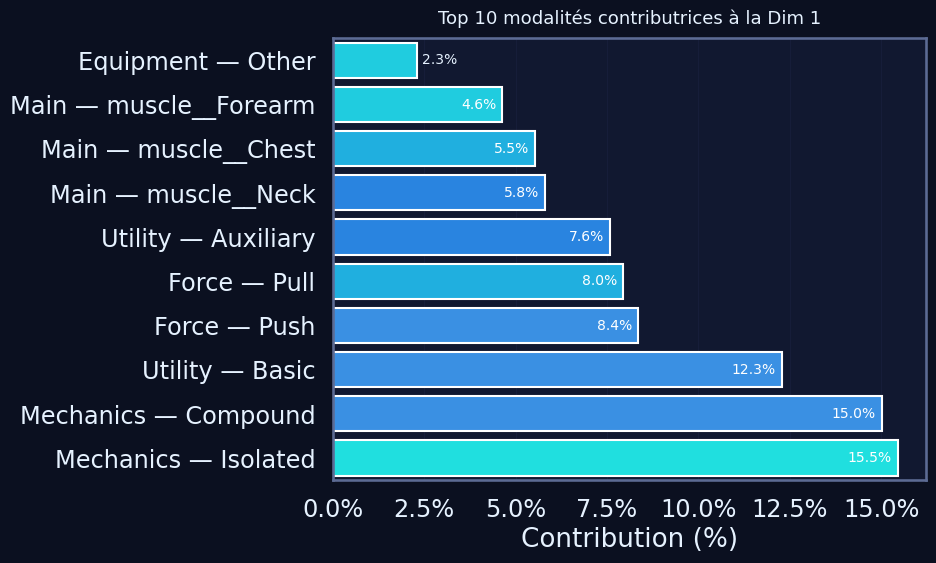

In [41]:
# Fallback palette si besoin
try:
    _ = palette_trainme
except NameError:
    sns.set_style("ticks"); sns.set_context("talk", font_scale=1.05)
    palette_trainme = sns.color_palette("deep")

contrib = mca.column_contributions_
assert 0 in contrib.columns, "La dimension 0 (Dim 1) est absente de column_contributions_."

dfc = contrib.copy()
dfc["Dim1_abs"] = dfc[0].abs()

# ✅ Index → var/mod (gère MultiIndex et index simples)
if isinstance(dfc.index, pd.MultiIndex):
    dfc = dfc.reset_index().rename(columns={"level_0": "var", "level_1": "mod"})
else:
    idx = dfc.index.astype(str)
    parts = pd.DataFrame(idx.str.split(r"__|_", n=1).tolist(), columns=["var", "mod"])
    parts["var"] = parts["var"].fillna("")
    # ⛑️ Patch: fournir une Series alignée à fillna
    idx_series = pd.Series(idx, index=parts.index)
    parts["mod"] = parts["mod"].fillna(idx_series)           # ← corrige le TypeError
    dfc = pd.concat([dfc.reset_index(drop=True), parts], axis=1)

# Labels compacts (wrap si trop long)
def make_label(v, m, width=28):
    lab = f"{str(v).strip()} — {str(m).strip()}"
    return "\n".join(textwrap.wrap(lab, width=width)) if len(lab) > width else lab

dfc["label"] = [make_label(v, m) for v, m in zip(dfc["var"], dfc["mod"])]

# Top 10
top_contrib = dfc.sort_values("Dim1_abs", ascending=False).head(10).copy()

# % si 0–1, sinon absolu
is_prop = top_contrib["Dim1_abs"].max() <= 1.0
top_contrib["plot_value"] = top_contrib["Dim1_abs"] * (100.0 if is_prop else 1.0)
x_label = "Contribution (%)" if is_prop else "Contribution (abs.)"

# Palette par variable
vars_unique = top_contrib["var"].unique().tolist()
palette_map = {v: palette_trainme[i % len(palette_trainme)] for i, v in enumerate(vars_unique)}
bar_colors = top_contrib["var"].map(palette_map)

# Ordre: petit → grand pour afficher le plus grand en haut
order_y = top_contrib.sort_values("plot_value")["label"]

plt.figure(figsize=(10, 6))
# 🩹 seaborn v0.14+: éviter le warning "palette sans hue" → utiliser color=None + palette via list colors
ax = sns.barplot(
    data=top_contrib,
    x="plot_value",
    y="label",
    order=order_y,
    palette=bar_colors.tolist()  # passe explicitement une liste de couleurs
)

# Annotations intelligentes
xmax = ax.get_xlim()[1]
for y, val in zip(ax.get_yticks(), top_contrib.set_index("label").loc[order_y, "plot_value"]):
    txt = f"{val:.1f}%" if is_prop else f"{val:.3f}"
    if val > 0.18 * xmax:
        ax.text(val - 0.01 * xmax, y, txt, va="center", ha="right", fontsize=10, color="white")
    else:
        ax.text(val + 0.01 * xmax, y, txt, va="center", ha="left", fontsize=10)

ax.set_title("Top 10 modalités contributrices à la Dim 1", fontsize=13, pad=10)
ax.set_xlabel(x_label); ax.set_ylabel("")
if is_prop:
    ax.xaxis.set_major_formatter(PercentFormatter(100))
ax.grid(True, axis="x", alpha=0.25)
plt.tight_layout()
plt.show()


## Détection d’anomalies et valeurs extrêmes

### Objectif

Identifier les observations atypiques du Gym Exercises Dataset, aussi bien
sur les variables numériques que sur certaines catégories.

L’objectif est de :

- repérer d’éventuels outliers numériques (notamment sur Difficulty (1-5)) ;
- détecter des modalités rares dans les principales variables catégorielles ;
- exploiter l’espace factoriel ACM pour repérer des exercices très éloignés
  de la structure moyenne du corpus.

Ces éléments permettront de décider si certaines observations doivent être
traitées de manière spécifique (retrait, recodage, regroupement) avant la
mise en place des modèles NLP et de recommandation.


### Interprétation attendue

À l’issue de cette section, l’analyse devra :

- indiquer si des niveaux de difficulté apparaissent comme clairement
  atypiques ou isolés ;
- quantifier le nombre d’outliers numériques identifiés par IQR/Z-score ;
- lister les modalités catégorielles très rares (ou quasi uniques) et
  discuter de leur impact potentiel sur les modèles ;
- repérer d’éventuels exercices fortement isolés dans le plan ACM et
  discuter de leur signification métier (exercice très spécifique, variante
  marginale, erreur possible).

L’objectif n’est pas forcément de supprimer ces cas, mais de les connaître
pour prendre des décisions éclairées lors du prétraitement.


### Imports & sélection des colonnes pertinentes

On commence par sélectionner les variables numériques et catégorielles
à analyser pour la détection d’anomalies.


In [42]:
# Variables numériques
num_cols = df.select_dtypes(include=["number"]).columns.tolist()
print("Variables numériques :", num_cols)

# Variables numériques métier (on met de côté parent_id si besoin)
num_for_outliers = [c for c in num_cols if c != "parent_id"]
print("Variables numériques analysées pour les outliers :", num_for_outliers)

# Variables catégorielles clés pour les modalités rares
cat_cols_outliers = [
    "Equipment",
    "Utility",
    "Mechanics",
    "Force",
    "Main_muscle",
]
cat_cols_outliers = [c for c in cat_cols_outliers if c in df.columns]
print("Variables catégorielles analysées pour les modalités rares :", cat_cols_outliers)


Variables numériques : ['Difficulty (1-5)', 'parent_id']
Variables numériques analysées pour les outliers : ['Difficulty (1-5)']
Variables catégorielles analysées pour les modalités rares : ['Equipment', 'Utility', 'Mechanics', 'Force', 'Main_muscle']


### Méthode IQR (Interquartile Range) — Outliers numériques

On utilise l’IQR (Q3 − Q1) pour repérer les observations situées très
au-delà de l’intervalle interquartile (en dehors de [Q1 − 1.5×IQR ; Q3 +
1.5×IQR]).


In [43]:
def detect_outliers_iqr(series, k=1.5):
    s = series.dropna()
    if s.empty:
        return pd.Series(False, index=series.index)
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr
    mask = (series < lower) | (series > upper)
    return mask.fillna(False)

outlier_stats = []
for col in num_cols:
    mask = detect_outliers_iqr(df[col], k=1.5)
    ratio = mask.mean() * 100
    outlier_stats.append((col, round(ratio, 2)))

outlier_df = pd.DataFrame(outlier_stats, columns=["Variable", "Outliers_IQR (%)"]).sort_values("Outliers_IQR (%)", ascending=False)
display(outlier_df)


,Variable,Outliers_IQR (%)
0,Difficulty (1-5),2.59
1,parent_id,0.00


### Visualisation : boxplots des variables les plus affectées

On visualise les variables numériques présentant des outliers selon la
méthode IQR.


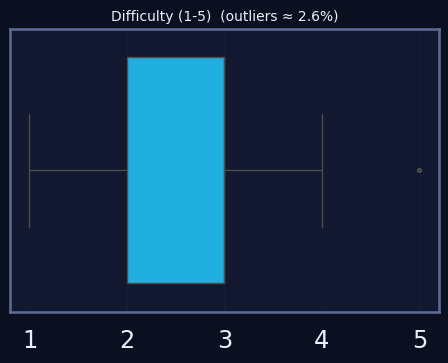

In [44]:
top_outliers = outlier_df[outlier_df["Outliers_IQR (%)"] > 0]["Variable"].tolist()  # montrer celles qui ont au moins 1 outlier

if top_outliers:
    n = min(6, len(top_outliers))
    ncols = 3
    nrows = (n + ncols - 1) // ncols
    plt.figure(figsize=(14, 4*nrows))
    for i, col in enumerate(top_outliers[:n], 1):
        ax = plt.subplot(nrows, ncols, i)
        sns.boxplot(x=df[col], color=palette_trainme[i % len(palette_trainme)], fliersize=2)
        ratio = float(outlier_df.loc[outlier_df["Variable"]==col, "Outliers_IQR (%)"].values[0])
        ax.set_title(f"{col}  (outliers ≈ {ratio:.1f}%)", fontsize=10)
        ax.set_xlabel("")
        ax.grid(True, axis="x", alpha=0.2)
    plt.tight_layout()
    plt.show()
else:
    print("ℹ️ Aucun outlier détecté par IQR sur les variables numériques sélectionnées.")


### Z-Score complémentaire (|Z| > 3)

On complète l’IQR par un repérage simple via le Z-score, en considérant
comme atypiques les observations dont |Z| dépasse 3.


In [47]:
if num_cols:
    z_scores = pd.DataFrame(index=df.index)
    for col in num_cols:
        s = df[col]
        z = pd.Series(zscore(s.dropna()), index=s.dropna().index)
        z_scores[col] = z.reindex(df.index)
    outlier_z = (z_scores.abs() > 3).sum(axis=0) / len(df) * 100
    outlier_z_df = pd.DataFrame({"Variable": num_cols, "Outliers_Z>3 (%)": outlier_z.values}).sort_values("Outliers_Z>3 (%)", ascending=False)
    display(outlier_z_df)
else:
    print("ℹ️ Z-score non calculé (aucune variable numérique).")

,Variable,Outliers_Z>3 (%)
0,Difficulty (1-5),0.0
1,parent_id,0.0


### Modalités rares (catégorielles) — détection simple

On identifie les modalités très peu représentées dans les variables
catégorielles principales. Ces modalités rares peuvent compliquer
l’apprentissage des modèles et justifier des regroupements.


In [48]:
rare_modalities = {}

min_count = 3      # seuil minimal d’occurrences
min_pct = 0.5      # ou < 0.5 % des lignes

n_rows = len(df)

for col in cat_cols_outliers:
    counts = df[col].value_counts()
    mask_rare = (counts < min_count) | (counts / n_rows * 100 < min_pct)
    rares = counts[mask_rare]
    rare_modalities[col] = rares

for col, rares in rare_modalities.items():
    print(f"\n--- Modalités rares pour {col} ---")
    if rares.empty:
        print("Aucune modalité rare selon les seuils définis.")
    else:
        display(
            pd.DataFrame(
                {
                    "count": rares,
                    "pct": (rares / n_rows * 100).round(3),
                }
            )
        )



--- Modalités rares pour Equipment ---


,count,pct
Equipment,,
Assisted (machine),3,0.486
Lever,3,0.486
Suspension,2,0.324
Plyometric,2,0.324
Assisted (partner),2,0.324
Sled (selectorized),1,0.162
Sled (plate loaded),1,0.162
Band Resistive,1,0.162
Smith​​​​​​​,1,0.162



--- Modalités rares pour Utility ---


,count,pct
Utility,,
Plyometric,2,0.324



--- Modalités rares pour Mechanics ---
Aucune modalité rare selon les seuils définis.

--- Modalités rares pour Force ---


,count,pct
Force,,
Push & Pull,1,0.162



--- Modalités rares pour Main_muscle ---
Aucune modalité rare selon les seuils définis.


### Observations atypiques via l'espace ACM (MCA)

On utilise enfin les coordonnées factorielle de l’ACM pour repérer des
exercices très éloignés du “noyau central” du corpus, ce qui peut
signaler des mouvements rares ou très spécifiques.


Top 15 exercices les plus atypiques dans l'espace ACM :


,Exercise Name,Equipment,Main_muscle,Utility,Mechanics,Force,Difficulty (1-5),acm_distance
308,Clap Push-up,Plyometric,Chest,Plyometric,Compound,Push,4,3.407015
309,Depth Push-up,Plyometric,Chest,Plyometric,Compound,Push,3,3.407015
224,Archer Pull-up,Band-assisted,Back,Basic,Compound,Pull,5,2.227604
226,Pull-up,Band-assisted,Back,Basic,Compound,Pull,4,2.227604
225,Chin-up,Band-assisted,Back,Basic,Compound,Pull,4,2.227604
227,Pull-up: Parallel Grip,Band-assisted,Back,Basic,Compound,Pull,4,2.227604
582,Donkey Calf Raise,Sled,Calves,Basic,Isolated,Push,3,2.198897
583,Lying Calf Press,Sled,Calves,Basic,Isolated,Push,2,2.198897
585,Standing Calf Raise,Sled,Calves,Basic,Isolated,Push,2,2.198897
581,45° Calf Raise,Sled,Calves,Basic,Isolated,Push,3,2.198897


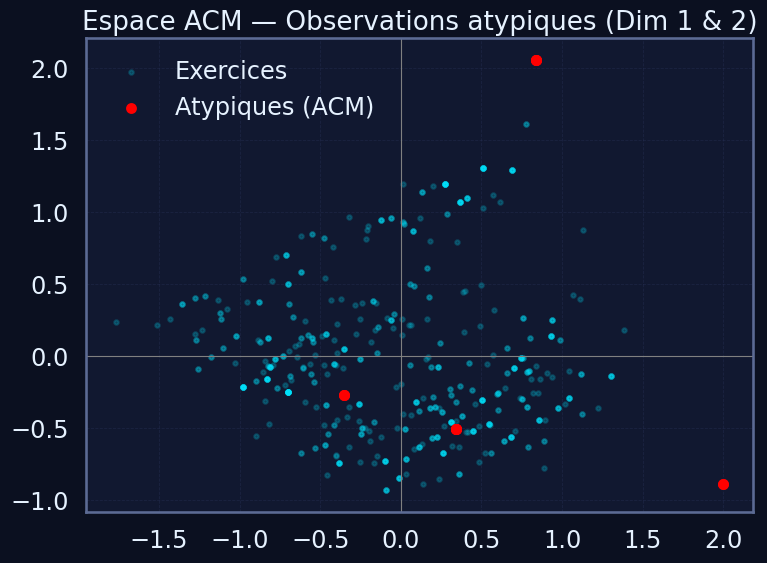

In [49]:
# Vérification rapide
assert "mca" in globals(), "L'objet 'mca' doit être défini dans la section ACM."
assert "df_acm" in globals(), "Le DataFrame 'df_acm' doit être défini dans la section ACM."

# Coordonnées des individus dans l'espace factoriel
coords = mca.transform(df_acm)

# Distance euclidienne à l'origine (axes principaux)
dist = np.sqrt((coords**2).sum(axis=1))
dist.name = "acm_distance"

# On ajoute la distance au DataFrame original pour inspection
df_acm_outliers = df.copy()
df_acm_outliers["acm_distance"] = dist

# Top exercices les plus éloignés
top_k = 15
acm_outliers = df_acm_outliers.sort_values("acm_distance", ascending=False).head(top_k)

print(f"Top {top_k} exercices les plus atypiques dans l'espace ACM :")
display(
    acm_outliers[
        [
            "Exercise Name",
            "Equipment",
            "Main_muscle",
            "Utility",
            "Mechanics",
            "Force",
            "Difficulty (1-5)",
            "acm_distance",
        ]
    ]
)

# Visualisation simple (Dim 1 & 2) avec mise en évidence des points extrêmes
coords_2d = coords.iloc[:, :2]
coords_2d.columns = ["Dim1", "Dim2"]

plt.figure(figsize=(8, 6))
plt.scatter(coords_2d["Dim1"], coords_2d["Dim2"], s=10, alpha=0.2, label="Exercices")
plt.scatter(
    coords_2d.loc[acm_outliers.index, "Dim1"],
    coords_2d.loc[acm_outliers.index, "Dim2"],
    s=40,
    color="red",
    label="Atypiques (ACM)",
)
plt.axhline(0, color="grey", linewidth=0.8)
plt.axvline(0, color="grey", linewidth=0.8)
plt.title("Espace ACM — Observations atypiques (Dim 1 & 2)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()
